<table align="left"  width="100%"> <tr>
        <td  style="background-color:#ffffff;">
            <a href="https://qworld.net" target="_blank"><img src="../images/qworld.jpg" width="35%" align="left"> </a></td>
        <td style="background-color:#ffffff;vertical-align:bottom;text-align:right;">
            prepared by Maksim Dimitrijev (<a href="https://qworld.net/index.php/qlatvia/" target="_blank">QLatvia</a>)
        </td>        
</tr></table>

<table width="100%"><tr><td style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;text-align:right;">This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros. </td></tr></table>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\qgate}[1]{ \mathop{\textit{#1} } }$

<h1> <font color="blue"> Solutions for </font>  Multiqubit operations </h1>

<a id="task1"></a>
<h3> Task 1 </h3>

Suppose that our quantum computer has architecture like Melbourne device seen on picture. Connections between numbers of qubits show between which qubits controlled operations and $\qgate{SWAP}$ are allowed.

Perform Hadamard operation on qubit 0 and swap it sequentially to qubit 8, and perform a $\qgate{CNOT}$ operation with qubit 7.

<img src="../images/10_ibmq_systems.jpg" width="75%">

<h3> Solution </h3>

In [15]:
import pennylane as qp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

    State  Count  Probability
000000000    503        0.503
100000010    497        0.497


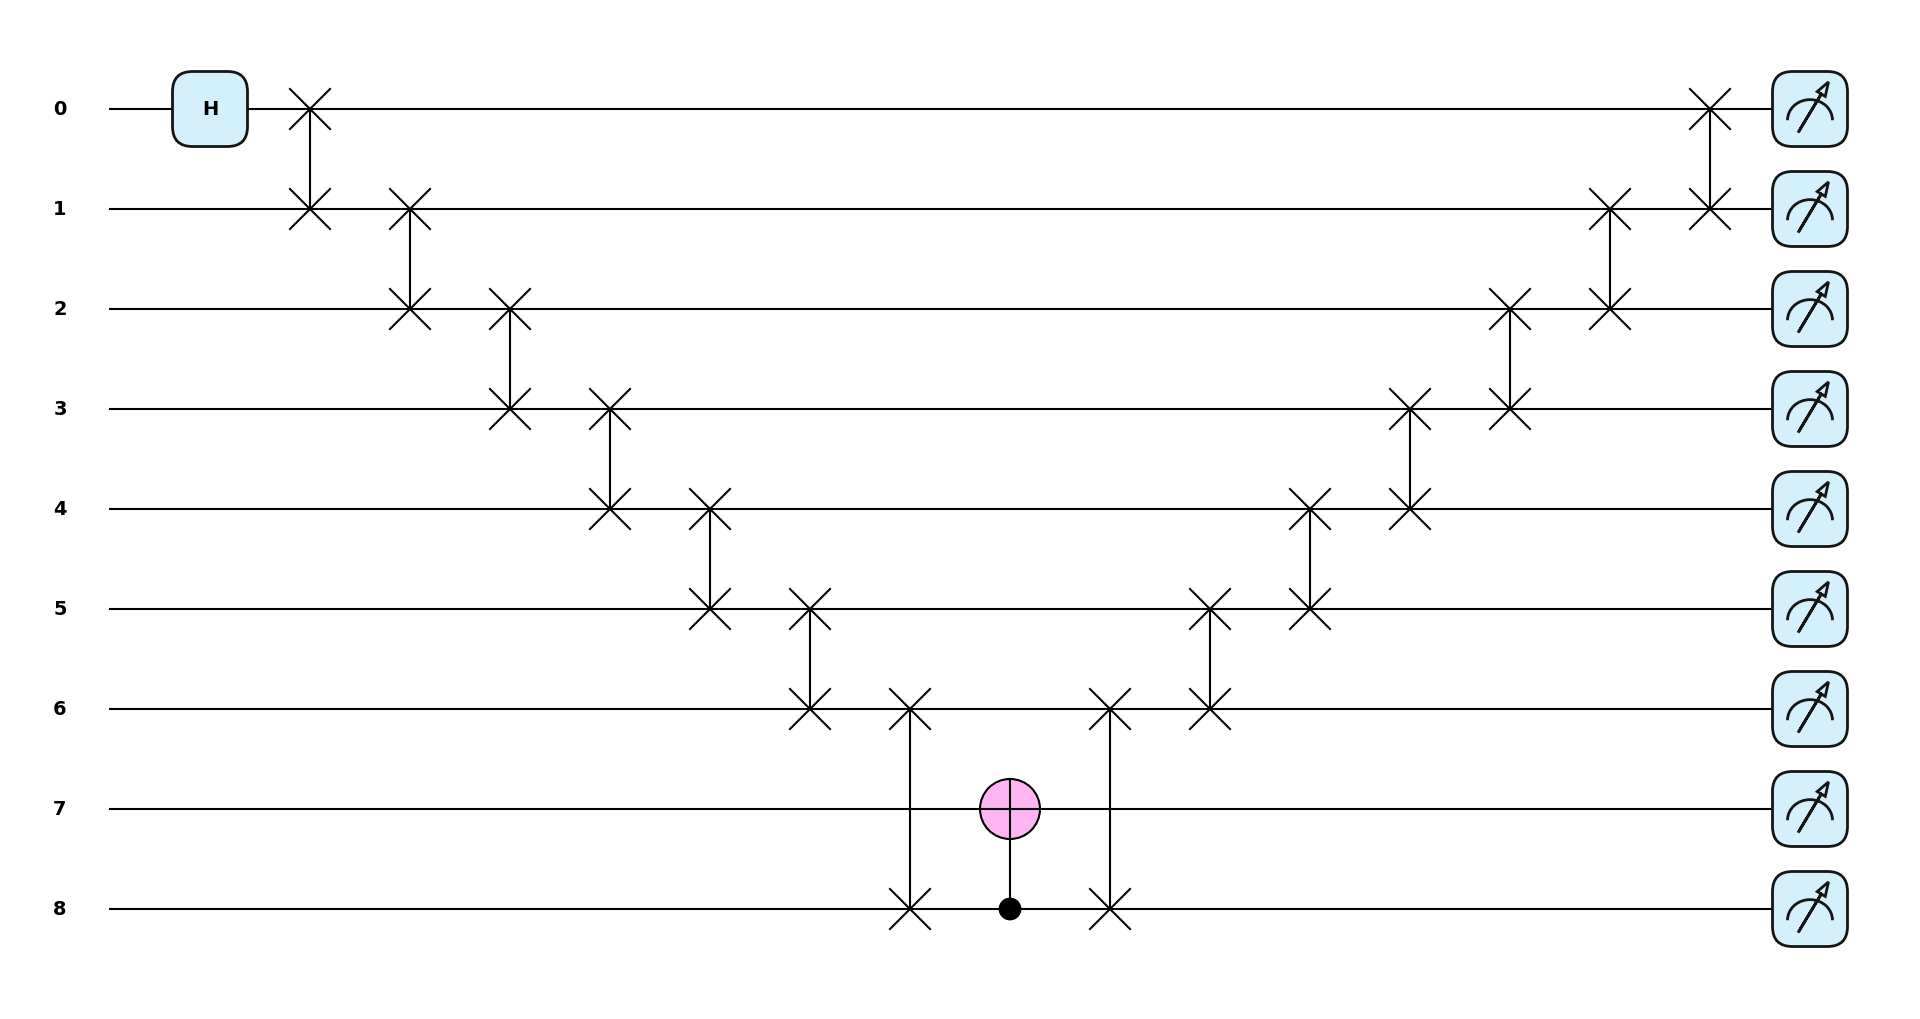

In [16]:
dev = qp.device("default.qubit", wires=9)

@qp.set_shots(shots=1000)
@qp.qnode(dev)
def circuit():
    qp.Hadamard(wires=0)
    qp.SWAP(wires=[0, 1])
    qp.SWAP(wires=[1, 2])
    qp.SWAP(wires=[2, 3])
    qp.SWAP(wires=[3, 4])
    qp.SWAP(wires=[4, 5])
    qp.SWAP(wires=[5, 6])
    qp.SWAP(wires=[6, 8])
    qp.CNOT(wires=[8, 7])
    qp.SWAP(wires=[6, 8])
    qp.SWAP(wires=[5, 6])
    qp.SWAP(wires=[4, 5])
    qp.SWAP(wires=[3, 4])
    qp.SWAP(wires=[2, 3])
    qp.SWAP(wires=[1, 2])
    qp.SWAP(wires=[0, 1])
    return qp.counts()

counts = circuit()

df = pd.DataFrame(list(counts.items()), columns=["State", "Count"])
df["Probability"] = df["Count"] / df["Count"].sum()
print(df.to_string(index=False))

fig, ax = qp.drawer.draw_mpl(circuit, style="pennylane")()
plt.show()

<a id="task3"></a>
<h3> Task 3 </h3>

Create a method named `fredkin` and implement Fredkin gate using $\qgate{CNOT}$ and $\qgate{CCNOT}$ operators. Use `qp.matrix` to check the unitary matrix corresponding to your circuit.

#### <h3> Solution </h3>

In [17]:
>M<nbvc 
      qp.Toffoli(wires=[2, 1, 0])
    qp.CNOT(wires=[0, 1])
    return qp.state()

    1    0    0    0    0    0    0    0
    0    1    0    0    0    0    0    0
    0    0    1    0    0    0    0    0
    0    0    0    0    0    1    0    0
    0    0    0    0    1    0    0    0
    0    0    0    1    0    0    0    0
    0    0    0    0    0    0    1    0
    0    0    0    0    0    0    0    1


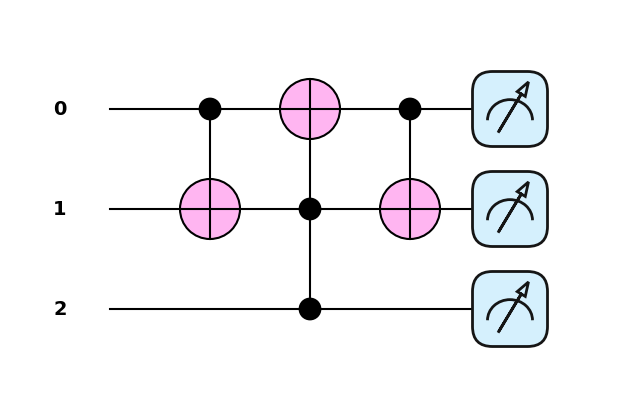

In [18]:
circuit = fredkin()

u = np.round(qp.matrix(fredkin)(), 3)
for i in range(len(u)):
    s=""
    for j in range(len(u)):
        val = str(u[i][j].real)
        while(len(val)<5): val  = " "+val
        s = s + val
    print(s)

fig, ax = qp.drawer.draw_mpl(fredkin, style="pennylane")()
plt.show()